# Forward Pricing of Stocks using Python

**Stock Name:** ITC Ltd

**Ticker:** ITC

In [1]:
# Import required libraries
import yfinance as yf
import pandas as pd
import numpy as np
from IPython.display import display
import mplfinance as mpf

In [2]:
itc = yf.Ticker('ITC.NS')

# Download 6 month historical data for ITC stock
pd.options.display.float_format = '{:.2f}'.format
data = itc.history(period='6mo')
data.tail(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-10-21 00:00:00+05:30,413.50,413.95,412.35,412.85,1142130,0.00,0.00
2025-10-23 00:00:00+05:30,416.00,420.45,413.55,415.95,24305990,0.00,0.00
2025-10-24 00:00:00+05:30,415.95,417.95,413.45,416.80,14935678,0.00,0.00
2025-10-27 00:00:00+05:30,417.00,422.70,416.60,420.65,11603679,0.00,0.00
2025-10-28 00:00:00+05:30,420.50,421.65,415.90,417.90,17163147,0.00,0.00
2025-10-29 00:00:00+05:30,418.20,422.20,416.05,421.60,11470661,0.00,0.00
2025-10-30 00:00:00+05:30,421.60,421.70,416.15,418.75,12938674,0.00,0.00
2025-10-31 00:00:00+05:30,420.50,426.40,418.20,420.35,18599864,0.00,0.00
2025-11-03 00:00:00+05:30,419.95,421.65,413.30,413.95,7635440,0.00,0.00


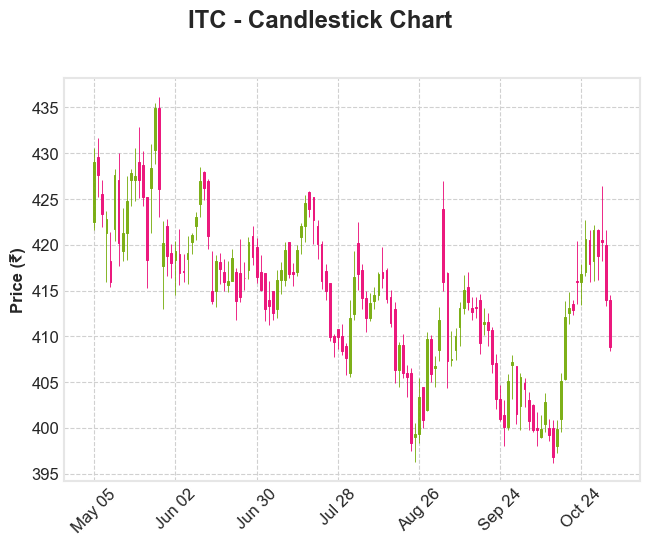

In [3]:
# Plot a candlestick chart for ITC stock
mpf.plot(data, type='candle', style='binance', title=f"ITC - Candlestick Chart", ylabel='Price (₹)') 

In [4]:
#Estimate parameters
spot = data['Close'].iloc[-1] 

r = 0.0546 # Risk Free Rate estimated from 91day Tbill yield as on 24/10/25

q = itc.info.get('dividendYield', 0) / 100 # Latest annualised dividend yield data available on Yahoo Finance

print("--- Estimated Parameters ---")
print(f"Spot Price: ₹{spot:.2f}")
print(f"Risk Free Rate: {r*100:.2f}%")
print(f"Dividend Yield: {q*100:.2f}%")

--- Estimated Parameters ---
Spot Price: ₹408.80
Risk Free Rate: 5.46%
Dividend Yield: 3.79%


In [ ]:
#Estimate 1m, 3m and 6m theoretical forward prices using formula F = S * e ^ (r-q)*T
F1m = spot * np.exp((r - q) * (1/12))
F3m = spot * np.exp((r - q) * (3/12))
F6m = spot * np.exp((r - q) * (6/12))

#Display table of forward prices
forward = pd.DataFrame({    
    'Maturity period': ['1 Month', '3 Months', '6 Months'],
    'Spot Price (₹)': [spot, spot, spot],
    'Annual Risk Free Rate (%)': [r*100, r*100, r*100],
    'Annual Dividend Yield (%)': [q*100, q*100, q*100],
    'Theoretical Forward Price (₹)': [F1m, F3m, F6m]
})

display(forward.head()
    .style.hide(axis="index")
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])
    .format(precision=2)
)

Maturity period,Spot Price (₹),Annual Risk Free Rate (%),Annual Dividend Yield (%),Theoretical Forward Price (₹)
1 Month,408.80,5.46,3.79,409.37
3 Months,408.80,5.46,3.79,410.51
6 Months,408.80,5.46,3.79,412.23
